# Seasonal Naive Model

### Table of Contents
1. [Step1: Importing required packages and dataset](#sec1)
2. [Step2: Rolling origin cross validation for MAE and MAPE](#sec2)
3. [Step 3: Evaluating prediction interval coverage(Winkler score, ACD,Empirical Coverage) of a 28day forecast](#sec3)
   1. [Step 3a: Simple train-test split](#sec4)
   2. [Step3b: Winkler score, ACD, Empirical coverage](#sec5)

#### Step1: Importing required packages and dataset <a id='sec1'></a>

In [1]:
import pandas as pd
import seaborn as sns
from forecast_tools.baseline import SNaive
from forecast_tools.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
)
from forecast_tools.metrics import (
   absolute_coverage_difference,
   winkler_score, coverage
)
from forecast_tools.model_selection import rolling_forecast_origin
from forecast_tools.model_selection import cross_validation_score

In [2]:
# importing pediatric dataset on daily emergency attendances
ed_daily = pd.read_csv(
    "paediatrics_train.csv", parse_dates=True, index_col="date", dayfirst=False
)
ed_daily.index.freq = "D"
ed_attend = ed_daily.paed_ed_attends

#### Step2: Rolling origin cross validation for MAE and MAPE <a id='sec2'></a>

In [3]:
# creating a seasonal naive model
sn = SNaive(7)


def perf_metrics(data, model, metric):
    """
    Calculates performance metrics for a model using
    cross validation folds over a horizon of 7,14,21 and 28 days
    it uses a minimum training size of 916 and a forward step of 28days

    Parameters:
    ----------
    data: pandas.Series
          The dataset used for cross validation splits
    model: naive model used in training and testing folds
    metrics: float
             performance metrics for assessing point forecast error

    Return:
    -------
    Performance metrics of cross validation

    """
    min_train_size = 916
    cv = rolling_forecast_origin(
        train=data, min_train_size=min_train_size, horizon=28, step=28
    )
    horizons = [7, 14, 21, 28]
    scores = cross_validation_score(
        model=model, cv=cv, metric=metric, horizons=horizons, n_jobs=-1
    )

    return pd.DataFrame(scores, columns=horizons).mean()

In [4]:
# MAE over 7,14,21 and 28 horizons
perf_metrics(ed_attend, sn, mean_absolute_error)

7     11.000000
14     9.971429
21     9.828571
28    10.692857
dtype: float64

In [5]:
# MAPE over 7,14,21 and 28 horizons
perf_metrics(ed_attend, sn, mean_absolute_percentage_error)

7     22.466103
14    19.518517
21    18.966796
28    20.927771
dtype: float64

#### Step 3: Evaluating prediction interval coverage(Winkler score, ACD,Empirical Coverage) of a 28day forecast <a id='sec3'></a>

##### Step 3a: Simple train-test split <a id='sec4'></a>

In [6]:
# Creating a simple train-test split, training of 1028days and test of 28days
train = ed_attend.iloc[:-28]
test = ed_attend.iloc[-28:]

Text(0.5, 1.0, 'Daily Pediatrics ED attendances')

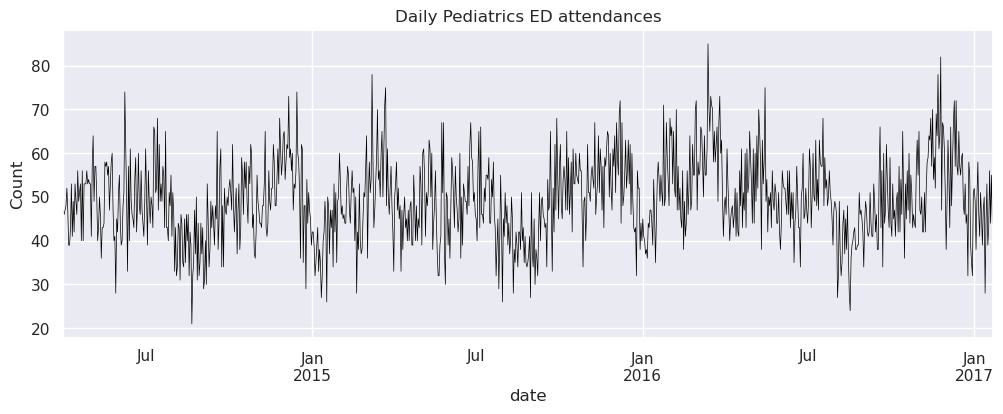

In [7]:
# plotting the training set data
sns.set()
ax = train.plot(figsize=(12, 4), color="black", linewidth=0.5, legend=False)
ax.set_ylabel("Count")
ax.set_title("Daily Pediatrics ED attendances")

##### Step3b: Winkler score, ACD, Empirical coverage <a id='sec5'></a>

In [8]:
# Assessing Seasonal naive 95% prediction interval
# using winkler score, absolute coverage difference and empirical coverage

sn.fit(train)
sn_preds, sn_interval = sn.predict(
    horizon=28, return_predict_int=True, alpha=[0.05]
)
winkler_sn = winkler_score(
    y_true=test, intervals=sn_interval[0], alpha=0.05
)
acd_sn = absolute_coverage_difference(
    y_true=test, intervals=sn_interval[0], alpha=0.05
)
cover_sn = coverage(y_true=test, pred_intervals=sn_interval[0])


print("Winkler_score:\n", round(winkler_sn, 2))
print("Absolute_coverage_diff:\n", round(acd_sn, 2))
print("Empirical Coverage:\n", round(cover_sn, 2))

Winkler_score:
 64.6
Absolute_coverage_diff:
 0.05
Empirical Coverage:
 1.0
